In [138]:
import numpy as np
import pandas as pd
import umap
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

inhibitory_cluster_1    53
inhibitory_cluster_0    36
excitory                28
Name: new_type, dtype: int64


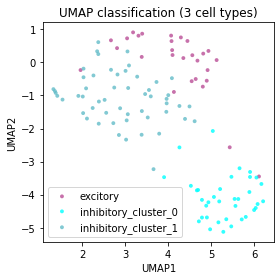

In [ ]:

seed_num = 96
np.random.seed(seed_num)

root_path = r'F:\jcy\humen_brain\revision20251127\Q4'

df = pd.read_excel(root_path + '\\all_neurons.xlsx')

cell_name = df['cell_name']
orig_type = df['type']   # 只有 excitory / inhibitory

cluster_df = pd.read_excel(root_path + '\\UMAP_KMeans_2clusters_cells.xlsx')

cluster0_names = set(cluster_df['cluster_0'].dropna())
cluster1_names = set(cluster_df['cluster_1'].dropna())

def map_new_type(row):
    if row['type'] == 'excitory':
        return 'excitory'
    elif row['cell_name'] in cluster0_names:
        return 'inhibitory_cluster_0'
    elif row['cell_name'] in cluster1_names:
        return 'inhibitory_cluster_1'
    else:
        return 'inhibitory_unknown'

df['new_type'] = df.apply(map_new_type, axis=1)

print(df['new_type'].value_counts())

df_data = df.drop(columns=['cell_name', 'type', 'new_type'])
# df_data = df.drop(columns=['cell_name','AHPAmp', 'AHP_latency', 'type', 'new_type'])
df_data.fillna(method='pad', inplace=True)

df_data_scale = StandardScaler().fit_transform(df_data)

umap_model = umap.UMAP(n_neighbors=15, n_components=2, random_state=seed_num)
umap_vals = umap_model.fit_transform(df_data_scale)

plt.figure(figsize=(4,4))

color_dict = {
    'excitory': '#ba4e96',
    'inhibitory_cluster_0': 'cyan',
    'inhibitory_cluster_1': '#63bcc8',
}

for cell_type, color in color_dict.items():
    idx = df['new_type'] == cell_type
    plt.scatter(
    umap_vals[idx, 0],
    umap_vals[idx, 1],
    s=15,
    c=color,
    label=cell_type,
    alpha=0.8,
    edgecolors='none',
    linewidths=0,
)

plt.legend()
plt.title('UMAP classification (3 cell types)')
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.savefig(root_path+f'\\clusetring ExN InN.pdf')
plt.tight_layout()
plt.show()